<a href="https://colab.research.google.com/github/chidiview-ui/shiny-telegram/blob/main/Spaceship_Game.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
first_name="chidi"
last_name="enenwata"
occupation="engineering"
address="enugu"
hometown="umuaga"
full_name=first_name + " " + last_name
print("Hello! I am"+ " " + full_name.title()+ " "+ "my hometown is" + " " + hometown.title() + " " +" " "and "  "my occupation is" + " " + occupation.title() +" " "I live in" + " " + address.title()+".")


Hello! I am Chidi Enenwata my hometown is Umuaga  and my occupation is Engineering I live in Enugu.


In [ ]:
!python --version

Python 3.12.13


In [ ]:
# Building PyGame Project


### Set up Virtual Display for Pygame

Since Colab runs in a cloud environment without a physical display, we need to use a virtual display server (Xvfb) to allow Pygame to render graphics. We'll use the `pyvirtualdisplay` library to manage this.

In [ ]:
# Install required packages for virtual display
!pip install -qq pyvirtualdisplay
!apt-get install -qq xvfb

In [ ]:
# Start the virtual display
from pyvirtualdisplay import Display

display = Display(visible=0, size=(1400, 900)) # You can adjust size as needed
display.start()

print("Virtual display started. Pygame output should now be captured.")

Virtual display started. Pygame output should now be captured.


In [ ]:
# Create an Empty PyGame Window

import sys

import pandas as pd

import pygame

import os
# os.environ['SDL_VIDEODRIVER'] = 'dummy' # This line has been commented out to enable graphical output

### Download Sample Image

Let's download a simple image to use in our Pygame display. We'll use a `bmp` file as it's generally well-supported by Pygame without additional libraries.

In [ ]:
!wget -q https://raw.githubusercontent.com/ehmatthes/pcc_2e/master/chapter_12/images/alien.bmp

In [ ]:
class Settings:
    """ A Class to store all settings for Spaceship."""

    def __init__(self):
        # Initialize the game's settings
        self.screen_width = 1200
        self.screen_height = 800
        self.bg_color = (230, 230, 230)

        # Spaceship settings
        self.spaceship_speed = 1.5

        # Bullet settings
        self.bullet_speed = 3.0
        self.bullet_width = 10  # Increased width for better visibility
        self.bullet_height = 30 # Increased height for better visibility
        self.bullet_color = (60, 60, 60)
        self.bullets_allowed = 3

In [ ]:
import pygame
from pygame.sprite import Group

def run_game():
    # Initialize Game and Create a Screen Object
    pygame.init()

    # Create a settings object
    ai_settings = Settings()

    screen = pygame.display.set_mode(
        (ai_settings.screen_width, ai_settings.screen_height))
    pygame.display.set_caption("Spaceship")

    # Make a group to store bullets in.
    bullets = Group()

    # The run_game function should now only set up the screen and settings,
    # not load specific game entities like the alien/spaceship.
    return screen, ai_settings, bullets

In [ ]:
import pygame

class Spaceship:
  def __init__(self, screen, image_path, settings):
    """ Initialize the Spaceship and set its starting position"""
    self.screen = screen
    self.settings = settings # Add settings to access speed

    # Load the Spaceship Image
    self.image = pygame.image.load(image_path)

    # Scale the image down to a more manageable size (e.g., 10% of screen width, maintaining aspect ratio)
    original_width, original_height = self.image.get_size()
    aspect_ratio = original_height / original_width
    new_width = int(self.screen.get_rect().width * 0.1)
    new_height = int(new_width * aspect_ratio)
    self.image = pygame.transform.scale(self.image, (new_width, new_height))

    # Get its rect after scaling
    self.rect = self.image.get_rect()
    self.screen_rect = screen.get_rect()

    # Start each new Spaceship at the bottom center of the screen
    self.rect.centerx = self.screen_rect.centerx
    self.rect.center = self.screen_rect.center

    # Store a decimal value for the spaceship's horizontal position
    self.x = float(self.rect.x)

    # Movement flags
    self.moving_right = False
    self.moving_left = False

  def update(self):
    """Update the spaceship's position based on movement flags."""
    if self.moving_right and self.rect.right < self.screen_rect.right:
        self.x += self.settings.spaceship_speed
    if self.moving_left and self.rect.left > 0:
        self.x -= self.settings.spaceship_speed

    # Update rect object from self.x
    self.rect.x = self.x

  def blitme(self):
    """ Draw the Spaceship at its Current Location"""
    self.screen.blit(self.image, self.rect)

In [ ]:
import pygame
from pygame.sprite import Sprite

class Bullet(Sprite):
    """A class to manage bullets fired from the spaceship"""

    def __init__(self, ai_settings, screen, spaceship):
        """Create a bullet object at the spaceship's current position."""
        super().__init__()
        self.screen = screen

        # Create a bullet rect at (0,0) and then set correct position.
        self.rect = pygame.Rect(0, 0, ai_settings.bullet_width,
            ai_settings.bullet_height)
        self.rect.centerx = spaceship.rect.centerx
        self.rect.top = spaceship.rect.top

        # Store the bullet's position as a decimal value.
        self.y = float(self.rect.y)

        self.color = ai_settings.bullet_color
        self.speed_factor = ai_settings.bullet_speed

    def update(self):
        """Move the bullet up the screen."""
        # Update the decimal position of the bullet.
        self.y -= self.speed_factor
        # Update the rect position.
        self.rect.y = self.y

    def draw_bullet(self):
        """Draw the bullet to the screen."""
        pygame.draw.rect(self.screen, self.color, self.rect)

In [ ]:
def check_keydown_events(event, ai_settings, screen, spaceship, bullets):
    """Respond to keypresses."""
    if event.key == pygame.K_RIGHT:
        spaceship.moving_right = True
    elif event.key == pygame.K_LEFT:
        spaceship.moving_left = True
    elif event.key == pygame.K_SPACE:
        fire_bullet(ai_settings, screen, spaceship, bullets)

def check_keyup_events(event, spaceship):
    """Respond to key releases."""
    if event.key == pygame.K_RIGHT:
        spaceship.moving_right = False
    elif event.key == pygame.K_LEFT:
        spaceship.moving_left = False

def check_events(ai_settings, screen, spaceship, bullets):
    """Respond to keypresses and mouse events."""
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            sys.exit()
        elif event.type == pygame.KEYDOWN:
            check_keydown_events(event, ai_settings, screen, spaceship, bullets)
        elif event.type == pygame.KEYUP:
            check_keyup_events(event, spaceship)

def fire_bullet(ai_settings, screen, spaceship, bullets):
    """Fire a bullet if limit not reached yet."""
    # Create a new bullet and add it to the bullets group.
    if len(bullets) < ai_settings.bullets_allowed:
        new_bullet = Bullet(ai_settings, screen, spaceship)
        bullets.add(new_bullet)

def update_bullets(bullets):
    """Update position of bullets and get rid of old bullets."""
    # Update bullet positions.
    bullets.update()

    # Get rid of bullets that have disappeared.
    for bullet in bullets.copy():
        if bullet.rect.bottom <= 0:
            bullets.remove(bullet)

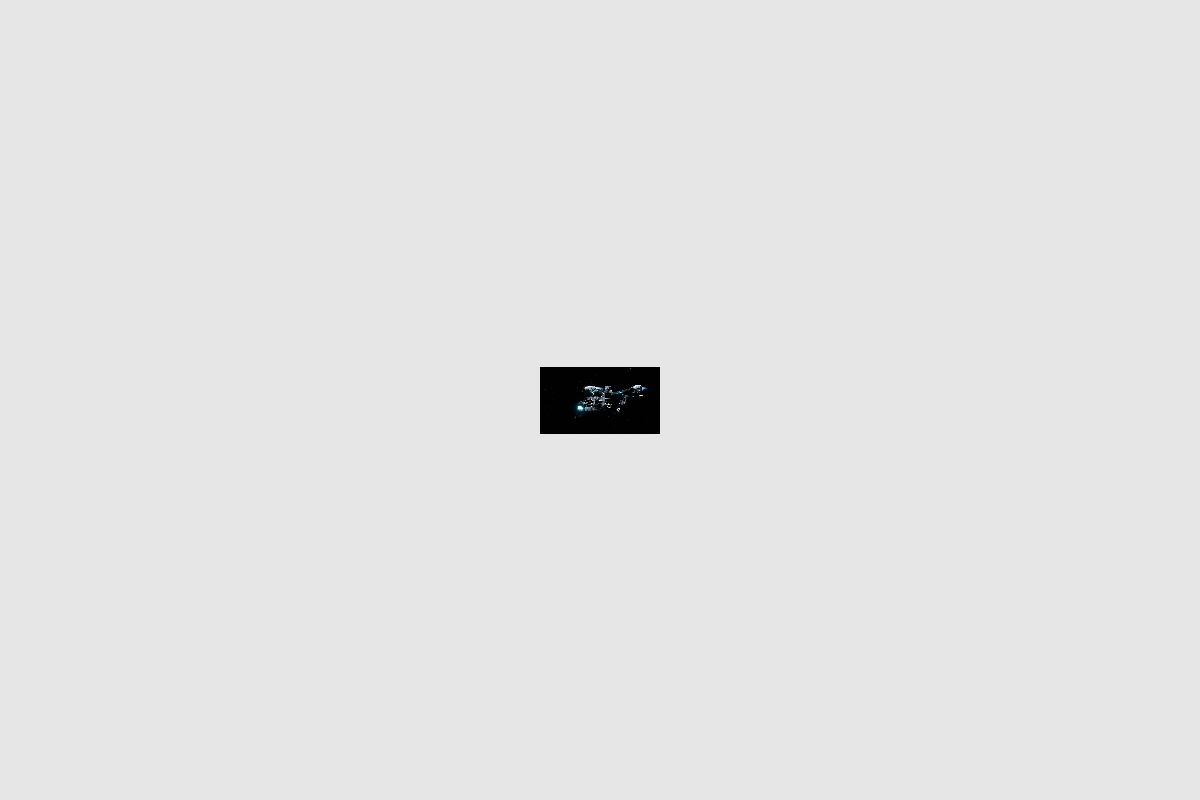

Displayed 500 frames. Game loop terminated.


In [ ]:
import io
import time
import pygame
from IPython.display import display, Image, clear_output
import os # Import os module

# Define the path to your image.
file_path = '/content/drive/MyDrive/Colab Notebooks/spaceship.bmp'




# Check if the image file exists, if not, download it.
if not os.path.exists(file_path):
    print(f"'{file_path}' not found. Attempting to download...")
    # Assuming the same URL from the previous !wget command
    !wget -q https://raw.githubusercontent.com/ehmatthes/pcc_2e/master/chapter_12/images/alien.bmp
    if os.path.exists(file_path):
        print(f"'{file_path}' downloaded successfully.")
    else:
        print(f"Failed to download '{file_path}'. Please check the URL or your connection.")
        # If download fails, we should probably exit or raise an error to prevent further FileNotFoundError
        raise FileNotFoundError(f"Image file '{file_path}' is still missing after attempted download.")

# Call run_game() to initialize Pygame and set the display mode, and get game objects
# The currently active 'run_game' function (in cell 5BwFhaa3-9l0) takes no arguments
# and returns `screen`, `ai_settings`, and `bullets`.
screen, ai_settings, bullets = run_game()

# Create a Spaceship instance, passing ai_settings
my_spaceship = Spaceship(screen, file_path, ai_settings)

running = True
frame_count = 0
max_frames = 500 # Set frame limit to 500

while running:
    # Watch for keyboard and mouse events. This code block is used to check events
    check_events(ai_settings, screen, my_spaceship, bullets)

    # Update spaceship's position
    my_spaceship.update()

    # Update bullets
    update_bullets(bullets)

    # Fill the screen with the background color from settings
    screen.fill(ai_settings.bg_color)

    # Draw the spaceship on the screen using its blitme method
    my_spaceship.blitme()

    # Draw bullets
    for bullet in bullets.sprites():
        bullet.draw_bullet()

    # Make the most recently drawn screen visible
    pygame.display.flip()  # Handles updating the entire screen

    # Capture and display the frame
    buffer = io.BytesIO()
    pygame.image.save(screen, buffer, 'png')
    clear_output(wait=True) # Clear previous frame for animation effect
    display(Image(data=buffer.getvalue()))

    frame_count += 1
    if frame_count >= max_frames:
        running = False # Exit loop after max_frames
        print(f"Displayed {max_frames} frames. Game loop terminated.")
        break # Exit the while loop

    time.sleep(0.05) # Add a small delay to control frame rate (approx 20 FPS)

pygame.quit() # Clean up pygame resources after loop exits